In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import matplotlib.pyplot as plt 


In [3]:
df = pd.read_csv("superstore.csv")


In [4]:
df.info()
df.isnull().sum()

df.drop_duplicates(inplace=True)

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'],errors = 'coerce')

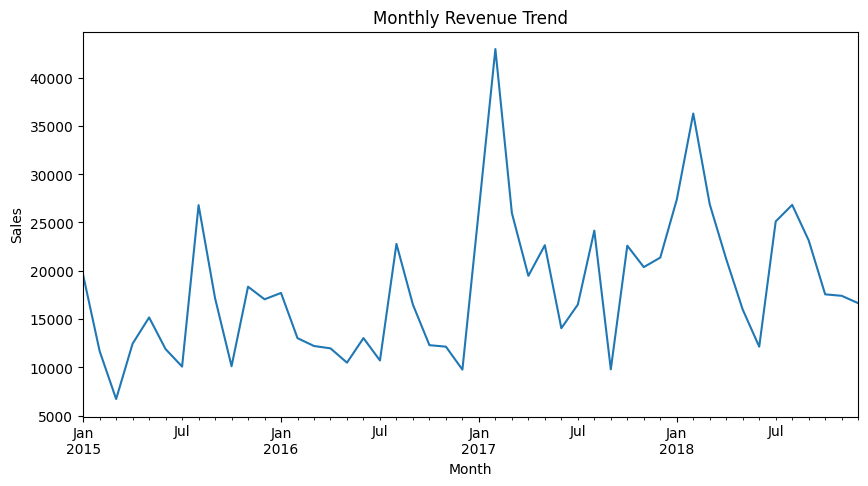

In [14]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()

monthly_sales.plot(figsize=(10,5), title="Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.savefig("monthly_sales.png")
plt.show()


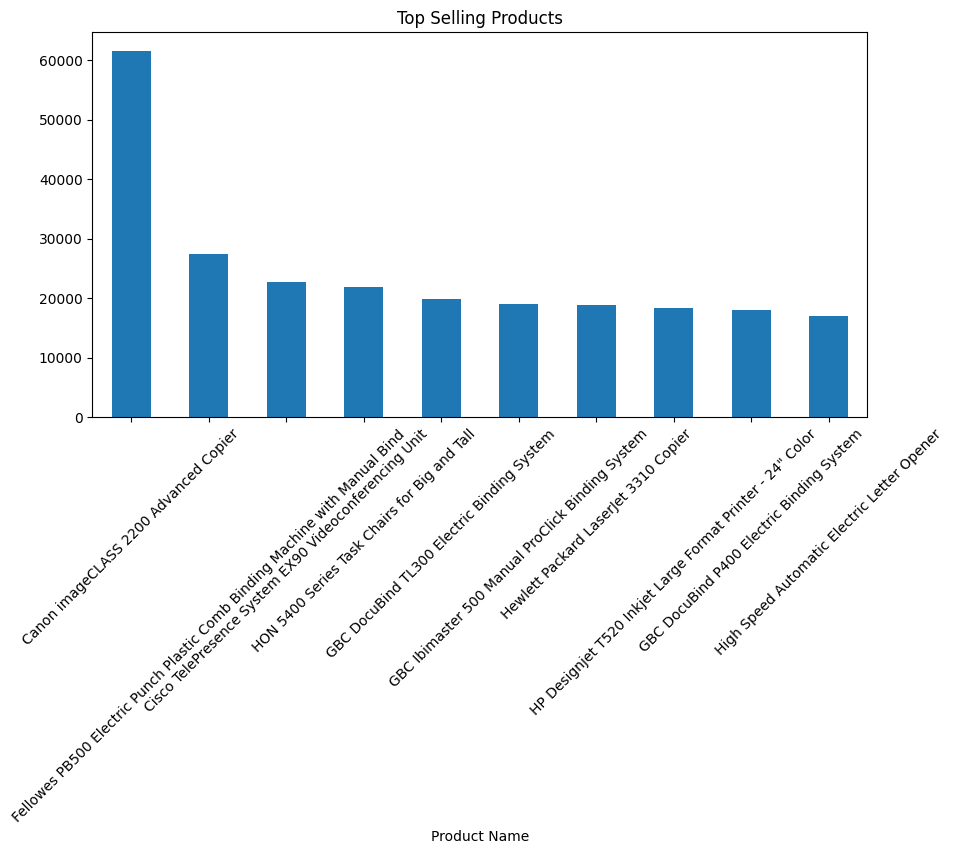

In [16]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5), title="Top Selling Products")
plt.xticks(rotation=45)
plt.savefig("top_products.png")
plt.show()


In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

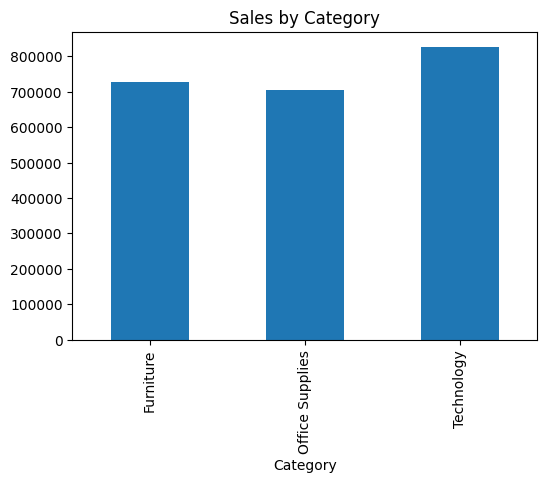

In [17]:
category_sales = df.groupby('Category')['Sales'].sum()

category_sales.plot(kind='bar', figsize=(6,4), title="Sales by Category")
plt.savefig("category_sales.png")
plt.show()

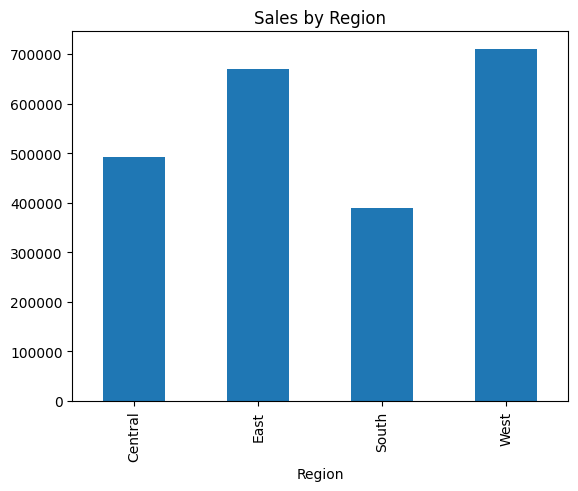

In [18]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='bar', title="Sales by Region")
plt.savefig("region_sales.png")
plt.show()

## Key Insights

- Sales show an overall increasing trend from 2015 to 2018, indicating business growth.
- Significant spikes in sales are observed during certain months, suggesting seasonal demand.
- A few top products contribute a large portion of total revenue.
- Technology category generates the highest sales among all categories.
- The West (or your highest region) region contributes the most to overall sales.
- Sales distribution varies significantly across categories and regions.